# Siemens- Bussines Case Project 2025/2026
**DATA VISUALIZATION AND PREPROCESSING NOTEBOOK**

**Project developed by Group V**:
   - Alano Gonçalves (20250457)
   - Catarina Martins (20221914)
   - João Carichas (20250507)
   - Marta Ribeiro (20221886)
   - Nicole Nogueira(20221961)

## 1. Import the needed libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil

## 2. Data importation

In [10]:
data= pd.read_excel("Case2_market_data_share.xlsx", sheet_name="Sheet1")
time= pd.read_excel("Case2_market_data_share.xlsx", sheet_name="Sheet2")
training=pd.read_excel("Case2_data_extract_share_fixed.xlsx", sheet_name="training")
validation=pd.read_excel("Case2_data_extract_share_fixed.xlsx", sheet_name="validation")

<div class="alert alert-block alert-info">

<a class="anchor" id="2. Trianing Exploration">    </a>
# Training Dataset
       
</div>


## 3. Data exploration and understanding

**METADATA:**


### 3.1. Data Overview

In [11]:
#overview the dataset
training.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4237 entries, 0 to 4236
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Anon Period              4237 non-null   int64 
 1   TGL Biz Desc             4237 non-null   object
 2   TGL Business Unit        4237 non-null   object
 3   TGL Business Segment     4237 non-null   object
 4   TGL Business Subsegment  4237 non-null   object
 5   Orders cons. (anon)      4237 non-null   int64 
 6   Revenue cons. (anon)     4237 non-null   int64 
dtypes: int64(3), object(4)
memory usage: 231.8+ KB


In [12]:
#first 20 rows
training.head(20)

,Anon Period,TGL Biz Desc,TGL Business Unit,TGL Business Segment,TGL Business Subsegment,Orders cons. (anon),Revenue cons. (anon)
0,1,SSI,SSI027,SSI02710,SSI02710,0,-390277
1,2,SSI,SSI027,SSI02710,SSI02710,0,334
2,3,SSI,SSI027,SSI02710,SSI02710,0,334
3,4,SSI,SSI027,SSI02710,SSI02710,0,1811758
4,5,SSI,SSI027,SSI02710,SSI02710,0,80112
5,6,SSI,SSI027,SSI02710,SSI02710,0,38468
6,7,SSI,SSI027,SSI02710,SSI02710,0,334
7,8,SSI,SSI027,SSI02710,SSI02710,0,334
8,9,SSI,SSI027,SSI02710,SSI02710,0,-37173
9,10,SSI,SSI027,SSI02710,SSI02710,0,38094


In [13]:
#descriptive statistics for numerical data
training.describe().round(2)

,Anon Period,Orders cons. (anon),Revenue cons. (anon)
count,4237.00,4.237000e+03,4.237000e+03
mean,22.51,4.007662e+07,3.597641e+07
std,12.24,7.041486e+07,6.378604e+07
min,1.00,-5.610188e+07,-1.201076e+07
25%,12.00,8.713890e+05,1.020192e+06
50%,23.00,9.281978e+06,8.850535e+06
75%,33.00,4.331285e+07,3.646013e+07
max,42.00,5.950944e+08,4.200361e+08


### 3.2. Checking Duplicates

In [14]:
#checking number of duplicates
training.duplicated().sum()

np.int64(0)

### 3.3. Checking Missing Values

In [15]:
#checking number of missing values
training.isna().sum()

Anon Period                0
TGL Biz Desc               0
TGL Business Unit          0
TGL Business Segment       0
TGL Business Subsegment    0
Orders cons. (anon)        0
Revenue cons. (anon)       0
dtype: int64

In [16]:
training.nunique()

Anon Period                  42
TGL Biz Desc                  1
TGL Business Unit             4
TGL Business Segment         24
TGL Business Subsegment     134
Orders cons. (anon)        3943
Revenue cons. (anon)       3958
dtype: int64

We should drop "TGL Biz Desc"

In [17]:
training[(training["Orders cons. (anon)"] == 0) & (training["Revenue cons. (anon)"] == 0)]

,Anon Period,TGL Biz Desc,TGL Business Unit,TGL Business Segment,TGL Business Subsegment,Orders cons. (anon),Revenue cons. (anon)
49,25,SSI,SSI027,SSI02710,SSI0271004,0,0
50,27,SSI,SSI027,SSI02710,SSI0271004,0,0
51,28,SSI,SSI027,SSI02710,SSI0271004,0,0
52,29,SSI,SSI027,SSI02710,SSI0271004,0,0
53,30,SSI,SSI027,SSI02710,SSI0271004,0,0
...,...,...,...,...,...,...,...
4083,40,SSI,SSI070,SSI07081,SSI0708199,0,0
4187,40,SSI,SSI070,SSI07082,SSI0708299,0,0
4230,23,SSI,SSI070,SSI07098,SSI07098,0,0
4231,24,SSI,SSI070,SSI07098,SSI07098,0,0


### 3.4 Checking Distribution

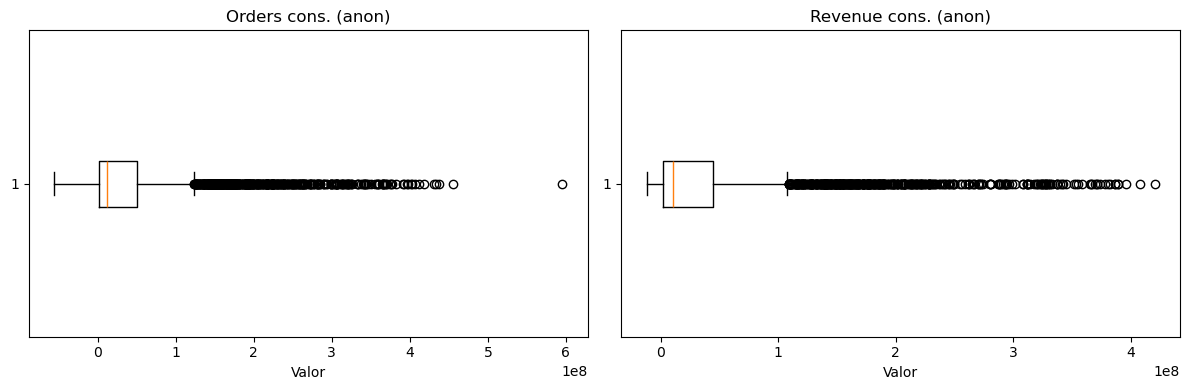

In [ ]:
cols = ["Orders cons. (anon)", "Revenue cons. (anon)"]

x = training[cols].apply(pd.to_numeric, errors="coerce")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, col in enumerate(cols):
    values = x[col].dropna()
    axes[i].boxplot(values, vert=False)
    axes[i].set_title(col)
    axes[i].set_xlabel("Valor")

plt.tight_layout()
plt.show()

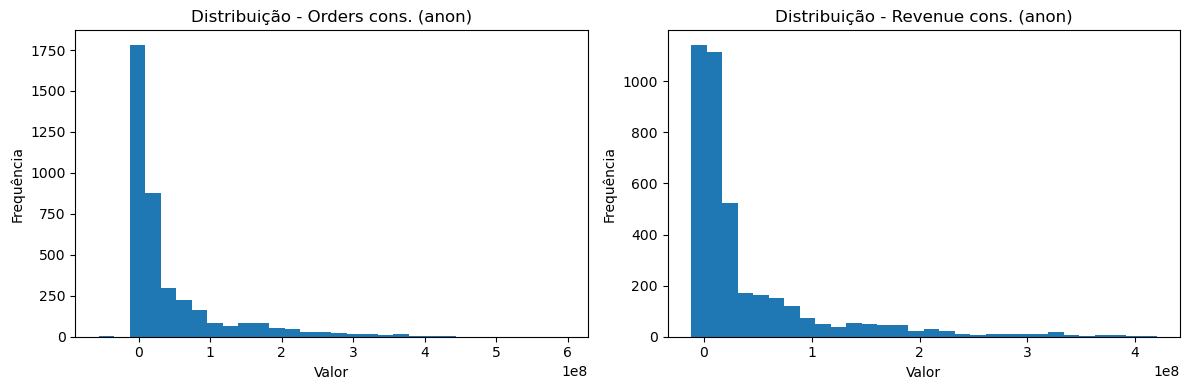

In [ ]:
cols = ["Orders cons. (anon)", "Revenue cons. (anon)"]

# converter para numérico
x = training[cols].apply(pd.to_numeric, errors="coerce")

# histogramas separados
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, col in enumerate(cols):
    values = x[col].dropna()
    axes[i].hist(values, bins=30)
    axes[i].set_title(f"Distribuição - {col}")
    axes[i].set_xlabel("Valor")
    axes[i].set_ylabel("Frequência")

plt.tight_layout()
plt.show()

### 3.5. Checking Incoherencies

In [37]:
training[training["Orders cons. (anon)"] < 0]

,Anon Period,Date,TGL Business Unit,TGL Business Segment,TGL Business Subsegment,Orders cons. (anon),Revenue cons. (anon)
95,10,2022-01-01,SSI027,SSI02780,SSI02780,-208,-208
271,32,2023-11-01,SSI027,SSI02782,SSI02782,-92992,-24882
444,31,2023-10-01,SSI027,SSI02782,SSI0278214,-3785,7993
453,40,2024-07-01,SSI027,SSI02782,SSI0278214,-99973,92345
472,41,2024-08-01,SSI027,SSI02784,SSI02784,-8189,17127
...,...,...,...,...,...,...,...
4064,32,2023-11-01,SSI070,SSI07081,SSI0708170,-12062,-44170
4067,35,2024-02-01,SSI070,SSI07081,SSI0708170,-13065,45939
4070,38,2024-05-01,SSI070,SSI07081,SSI0708170,-186224,176949
4119,35,2024-02-01,SSI070,SSI07082,SSI0708210,-2877775,14130325


In [38]:
training[training["Revenue cons. (anon)"] < 0]

,Anon Period,Date,TGL Business Unit,TGL Business Segment,TGL Business Subsegment,Orders cons. (anon),Revenue cons. (anon)
95,10,2022-01-01,SSI027,SSI02780,SSI02780,-208,-208
244,5,2021-08-01,SSI027,SSI02782,SSI02782,161740,-8227861
245,6,2021-09-01,SSI027,SSI02782,SSI02782,157859,-2808615
247,8,2021-11-01,SSI027,SSI02782,SSI02782,164094,-646583
251,12,2022-03-01,SSI027,SSI02782,SSI02782,3511916,-899699
265,26,2023-05-01,SSI027,SSI02782,SSI02782,1348828,-21164
271,32,2023-11-01,SSI027,SSI02782,SSI02782,-92992,-24882
461,42,2024-09-01,SSI027,SSI02782,SSI0278216,21953,-1205
1499,5,2021-08-01,SSI027,SSI02784,SSI0278460,7859,-50391
1671,5,2021-08-01,SSI027,SSI02786,SSI02786,29250,-515351


## 4. Data Preparation

### 4.1. Data preparation

In [34]:
training = training.drop(columns=["TGL Biz Desc"])

In [ ]:
# remover linhas em que Orders cons. (anon) OU Revenue cons. (anon) são 0
df = training[
    (training["Orders cons. (anon)"] != 0) &
    (training["Revenue cons. (anon)"] != 0)
]

### 4.2. Feature Engineering


In [36]:
time_unique = time[["Period", "DATE"]].drop_duplicates(subset="Period")
map_period_date = dict(zip(time_unique["Period"], time_unique["DATE"]))
training["Date"] = training["Anon Period"].map(map_period_date)

# mover a coluna "Date" para a primeira posição
col = training.pop("Date")
training.insert(1, "Date", col)
training.head()

,Anon Period,Date,TGL Business Unit,TGL Business Segment,TGL Business Subsegment,Orders cons. (anon),Revenue cons. (anon)
36,30,2023-09-01,SSI027,SSI02710,SSI0271002,1408682,1385872
37,31,2023-10-01,SSI027,SSI02710,SSI0271002,398269,572429
38,32,2023-11-01,SSI027,SSI02710,SSI0271002,483628,620954
39,33,2023-12-01,SSI027,SSI02710,SSI0271002,1973518,2209071
40,34,2024-01-01,SSI027,SSI02710,SSI0271002,465203,602052


<div class="alert alert-block alert-info">

<a class="anchor" id="2. Data Exploration">    </a>
# Data Dataset
       
</div>


**METADATA:**


### 3.1. Data Overview

In [39]:
#overview the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 78 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Period                                    180 non-null    int64  
 1   China_Core_Inflation_Rate                 178 non-null    float64
 2   China_Exports                             178 non-null    float64
 3   China_GDP                                 15 non-null     float64
 4   China_GDP_from_Construction               60 non-null     float64
 5   China_GDP_from_Manufacturing              60 non-null     float64
 6   China_Industrial_Production               176 non-null    float64
 7   China_Industrial_Production_Mom           170 non-null    float64
 8   China_Inflation_Rate                      178 non-null    float64
 9   China_Interest_Rate                       137 non-null    float64
 10  China_Steel_Production                

In [40]:
#first 20 rows
data.head(20)

,Period,China_Core_Inflation_Rate,China_Exports,China_GDP,China_GDP_from_Construction,China_GDP_from_Manufacturing,China_Industrial_Production,China_Industrial_Production_Mom,China_Inflation_Rate,China_Interest_Rate,...,United_States_Core_Inflation_Rate,United_States_Exports,United_States_GDP,United_States_GDP_from_Construction,United_States_GDP_from_Manufacturing,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Inflation_Rate,United_States_Interest_Rate,United_States_Steel_Production
0,-131,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6955.00
1,-130,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7264.00
2,-129,1.0,137.35,NaN,10710.5,76425.9,13.70,NaN,2.9,NaN,...,0.9,153.326,NaN,554.4,1925.9,8.5,0.2,1.1,NaN,7090.00
3,-128,1.1,145.45,NaN,NaN,NaN,13.40,NaN,3.3,NaN,...,0.9,156.763,NaN,NaN,NaN,7.7,0.4,1.2,0.25,6764.00
4,-127,1.1,139.26,NaN,NaN,NaN,13.90,NaN,3.5,NaN,...,0.9,157.769,NaN,NaN,NaN,6.9,0.4,1.1,0.25,6619.00
5,-126,1.1,144.99,NaN,18012.5,118221.6,13.30,NaN,3.6,NaN,...,0.8,158.624,NaN,549.2,1947.4,6.3,0.3,1.1,0.25,6605.00
6,-125,1.3,135.96,NaN,NaN,NaN,13.10,NaN,4.4,NaN,...,0.6,164.234,NaN,NaN,NaN,5.7,-0.3,1.2,0.25,6543.00
7,-124,1.5,153.29,NaN,NaN,NaN,13.30,NaN,5.1,NaN,...,0.8,165.621,NaN,NaN,NaN,5.4,0.1,1.1,0.25,6418.00
8,-123,1.7,154.14,6192.56,27259.3,165123.1,13.50,NaN,4.6,NaN,...,0.8,168.510,15048.97,545.1,1957.6,6.1,1.0,1.5,0.25,6648.00
9,-122,2.3,150.70,NaN,NaN,NaN,13.41,NaN,4.9,NaN,...,1.0,169.897,NaN,NaN,NaN,4.7,-0.2,1.6,0.25,7191.38


In [41]:
#descriptive statistics for numerical data
data.describe().round(2)

,Period,China_Core_Inflation_Rate,China_Exports,China_GDP,China_GDP_from_Construction,China_GDP_from_Manufacturing,China_Industrial_Production,China_Industrial_Production_Mom,China_Inflation_Rate,China_Interest_Rate,...,United_States_Core_Inflation_Rate,United_States_Exports,United_States_GDP,United_States_GDP_from_Construction,United_States_GDP_from_Manufacturing,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Inflation_Rate,United_States_Interest_Rate,United_States_Steel_Production
count,180.00,178.00,178.00,15.00,60.00,60.00,176.00,170.00,178.00,137.00,...,178.00,178.00,15.00,60.00,60.00,178.00,178.00,178.00,175.00,180.00
mean,-41.50,1.37,215.89,13031.13,33122.37,173068.40,7.42,0.65,2.08,4.21,...,2.59,209.07,20549.85,719.75,2129.46,1.03,0.07,2.60,1.43,6908.79
std,52.11,0.60,56.05,4130.32,22602.81,96035.07,5.04,3.29,1.49,0.69,...,1.40,31.90,4404.15,143.70,148.43,3.86,1.33,1.98,1.75,529.05
min,-131.00,-0.30,80.38,6192.56,4749.00,42670.30,-13.50,-22.10,-0.80,3.10,...,0.60,147.14,15048.97,533.20,1906.30,-17.20,-13.20,-0.20,0.25,4746.00
25%,-86.25,0.90,177.79,10208.83,13793.25,93960.05,5.40,0.44,1.30,3.70,...,1.70,188.11,17244.41,572.33,2000.15,-0.98,-0.28,1.42,0.25,6648.25
50%,-41.50,1.50,204.65,12537.56,28693.25,163199.35,6.30,0.55,2.00,4.30,...,2.10,198.92,19612.10,654.10,2104.35,1.60,0.10,2.10,0.25,6955.50
75%,3.25,1.80,263.34,16599.06,47756.28,227774.98,9.05,0.76,2.70,4.31,...,3.18,215.55,22610.57,867.68,2251.68,3.18,0.50,3.08,2.00,7270.16
max,48.00,2.50,339.66,18743.80,88862.80,404518.50,35.10,36.56,6.50,5.77,...,6.60,283.27,29184.89,904.40,2389.00,16.10,6.60,9.10,5.50,7960.90


### 3.2. Checking Duplicates

In [42]:
#checking number of duplicates
data.duplicated().sum()

np.int64(0)

### 3.3. Checking Missing Values

In [43]:
#checking number of missing values
data.isna().sum()

Period                                       0
China_Core_Inflation_Rate                    2
China_Exports                                2
China_GDP                                  165
China_GDP_from_Construction                120
                                          ... 
United_States_Industrial_Production          2
United_States_Industrial_Production_Mom      2
United_States_Inflation_Rate                 2
United_States_Interest_Rate                  5
United_States_Steel_Production               0
Length: 78, dtype: int64

In [47]:
data.nunique()

Period                                     180
China_Core_Inflation_Rate                   28
China_Exports                              176
China_GDP                                   15
China_GDP_from_Construction                 60
                                          ... 
United_States_Industrial_Production         88
United_States_Industrial_Production_Mom     34
United_States_Inflation_Rate                62
United_States_Interest_Rate                 17
United_States_Steel_Production             142
Length: 78, dtype: int64

In [46]:
data.nunique()[data.nunique() == 1]

Series([], dtype: int64)

### 3.5. Checking Distribution

### 3.7. Checking Incoherencies

## 4. Data Preparation

### 4.1. Data preparation

### 4.2. Feature Engineering